# EDA - Baseline Acadêmico

Este notebook realiza uma **Análise Exploratória de Dados (EDA)** do dataset consolidado com foco no baseline de desempenho acadêmico.

## Objetivo

Explorar e entender a distribuição e correlações das variáveis no dataset para:
- Verificar a balanceamento da variável target `defasado_bin`
- Avaliar dados faltantes (missing values)
- Analisar distribuições de variáveis numéricas
- Identificar correlações entre variáveis e o target
- Preparar insigths para o treinamento do modelo baseline

## Dados

- **Dataset**: `dataset_consolidado.csv` (3.030 registros, ~50 colunas)
- **Target**: `defasado_bin` (derivado de `Defasagem < 0`) - indica se o aluno está defasado
- **Foco**: Variáveis de desempenho acadêmico

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/dataset_consolidado.csv")

df['defasado_bin'] = (df['Defasagem'] < 0).astype(int)

print("Shape:", df.shape)
display(df.head())


Shape: (3030, 51)


,RA,Fase,Turma,Nome,AnoNascimento,Idade,Gênero,Ano ingresso,Instituição de ensino,Cg,...,Pedra,AnoReferencia,IPP,Destaque IPV.1,Avaliador5,Avaliador6,Escola,Ativo/ Inativo,Ativo/ Inativo.1,defasado_bin
0,RA-1,7,A,Aluno-1,2003,19.0,Menina,2016,Escola Pública,753.0,...,Quartzo,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,RA-2,7,A,Aluno-2,2005,17.0,Menina,2017,Rede Decisão,469.0,...,Ametista,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,RA-3,7,A,Aluno-3,2005,17.0,Menina,2016,Rede Decisão,629.0,...,Ágata,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,RA-4,7,A,Aluno-4,2005,17.0,Menino,2017,Rede Decisão,731.0,...,Quartzo,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,RA-5,7,A,Aluno-5,2005,17.0,Menina,2016,Rede Decisão,344.0,...,Ametista,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [7]:
print("Shape:", df.shape)
display(df.dtypes.head(20))
print("\nTotal de colunas:", len(df.columns))

Shape: (3030, 51)


RA                        object
Fase                      object
Turma                     object
Nome                      object
AnoNascimento              int64
Idade                    float64
Gênero                    object
Ano ingresso               int64
Instituição de ensino     object
Cg                       float64
Cf                       float64
Ct                       float64
Nº Av                    float64
Avaliador1                object
Rec Av1                   object
Avaliador2                object
Rec Av2                   object
Avaliador3                object
Rec Av3                   object
Avaliador4                object
dtype: object


Total de colunas: 51


defasado_bin
1    0.556766
0    0.443234
Name: proportion, dtype: float64

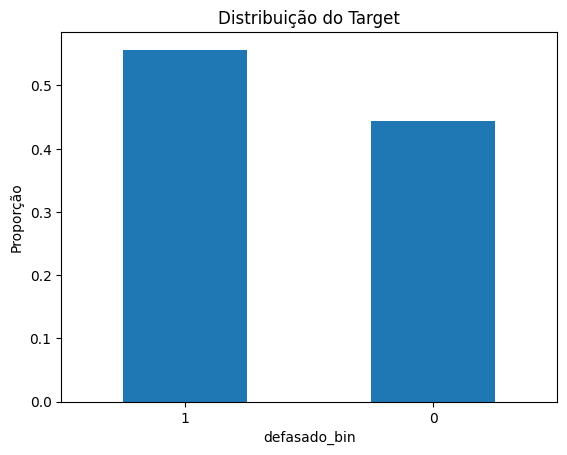

In [8]:
target_col = "defasado_bin"

target_dist = df[target_col].value_counts(normalize=True)

display(target_dist)

plt.figure()
target_dist.plot(kind="bar")
plt.title("Distribuição do Target")
plt.ylabel("Proporção")
plt.xticks(rotation=0)
plt.show()

if target_dist.min() < 0.10:
    print("⚠ Classes desbalanceadas detectadas (<10%). Priorizar AUPRC e F1.")

In [9]:
miss = df.isna().mean().sort_values(ascending=False)

display(miss[miss > 0].head(20))

high_missing = miss[miss > 0.05]
print(f"\nColunas com >5% missing: {len(high_missing)}")
display(high_missing)

Destaque IPV.1       1.000000
Avaliador6           0.998020
Avaliador5           0.951155
Rec Av4              0.902310
INDE_2_anos_atras    0.844224
Atingiu PV           0.716172
Destaque IEG         0.716172
Rec Av3              0.716172
Rec Av2              0.716172
Indicado             0.716172
Rec Av1              0.716172
Destaque IPV         0.716172
Ct                   0.716172
Rec Psicologia       0.716172
Cf                   0.716172
Cg                   0.716172
Destaque IDA         0.716172
Avaliador4           0.653135
Ingles               0.639934
Escola               0.618812
dtype: float64


Colunas com >5% missing: 36


Destaque IPV.1       1.000000
Avaliador6           0.998020
Avaliador5           0.951155
Rec Av4              0.902310
INDE_2_anos_atras    0.844224
Atingiu PV           0.716172
Destaque IEG         0.716172
Rec Av3              0.716172
Rec Av2              0.716172
Indicado             0.716172
Rec Av1              0.716172
Destaque IPV         0.716172
Ct                   0.716172
Rec Psicologia       0.716172
Cf                   0.716172
Cg                   0.716172
Destaque IDA         0.716172
Avaliador4           0.653135
Ingles               0.639934
Escola               0.618812
Ativo/ Inativo.1     0.618482
Ativo/ Inativo       0.618482
INDE_ano_anterior    0.574257
INDE_atual           0.368317
Pedra                0.355776
IPP                  0.342574
Avaliador3           0.328713
Idade                0.131683
Avaliador2           0.066997
Avaliador1           0.066997
Portugues            0.061056
Matematica           0.060726
IPV                  0.058746
IDA       

In [10]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category','bool']).columns.tolist()

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

Numéricas: 24
Categóricas: 27


Top 6 variáveis por variância: ['Cg', 'Cf', 'Ct', 'AnoNascimento', 'Idade', 'Ingles']


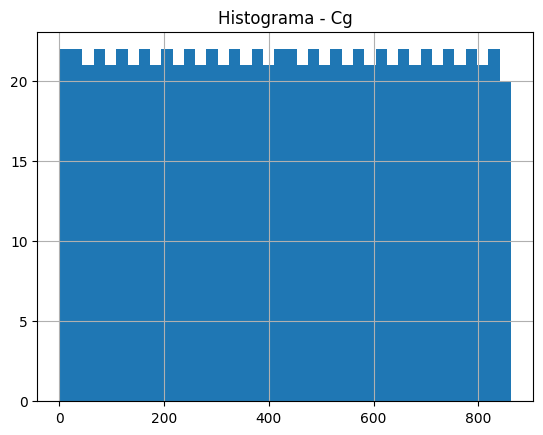

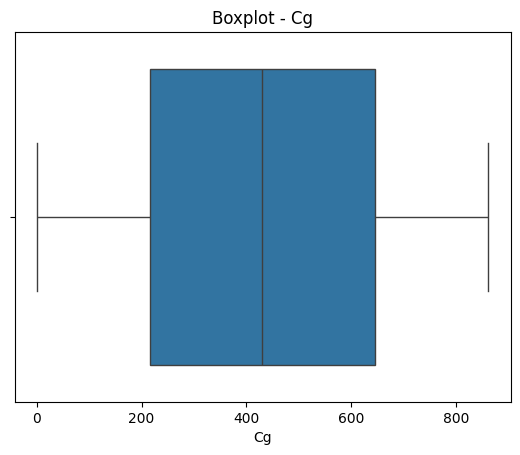

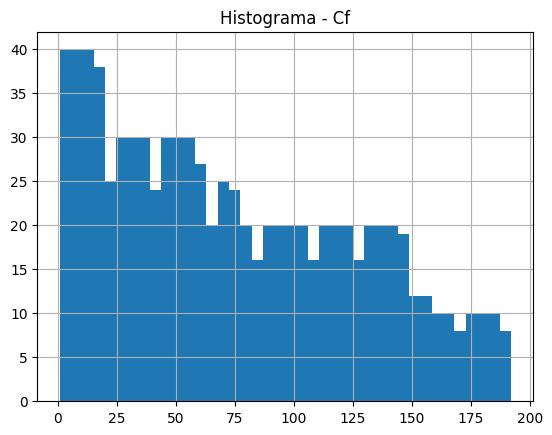

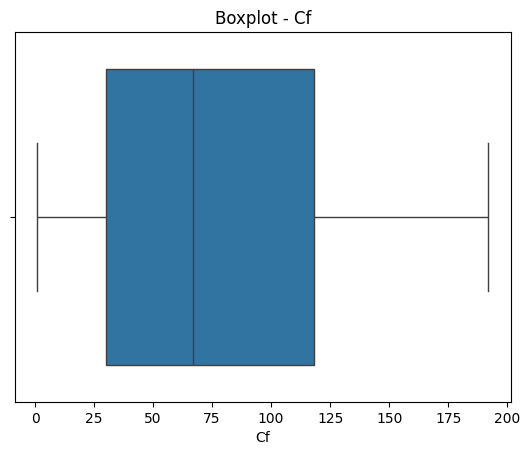

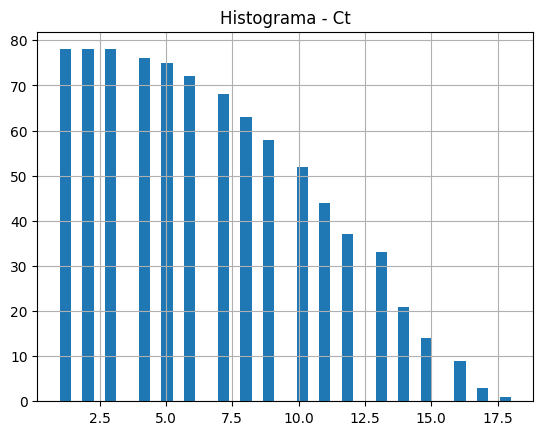

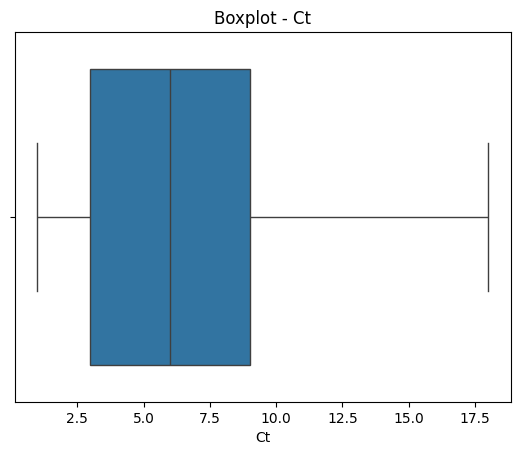

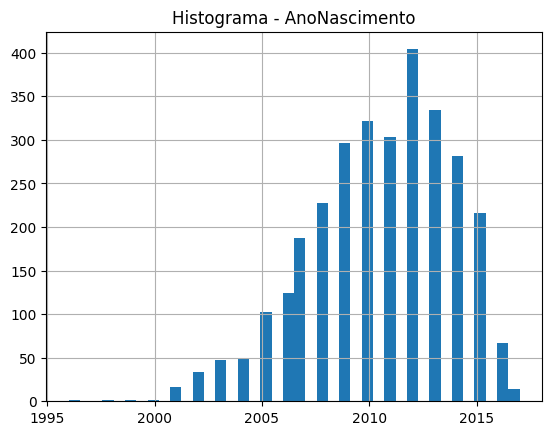

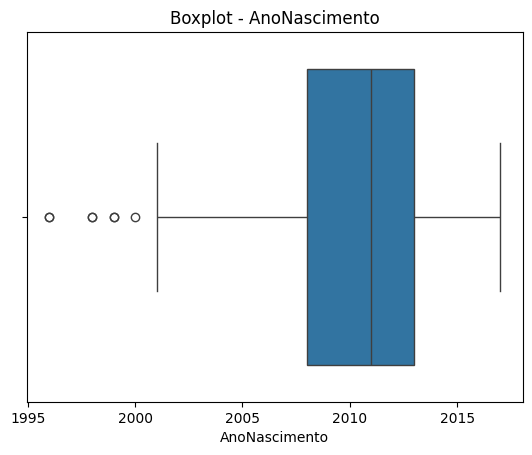

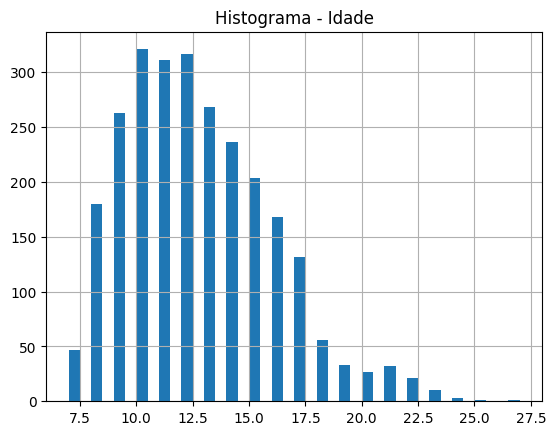

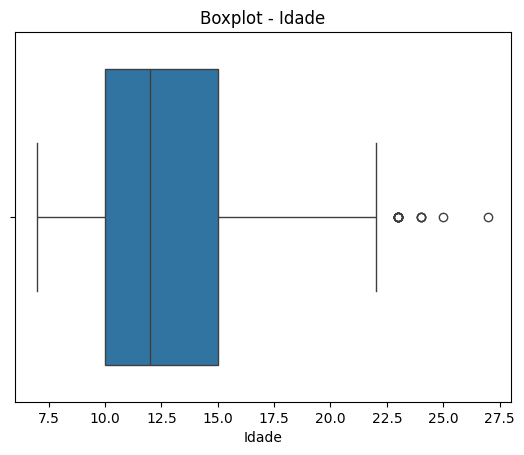

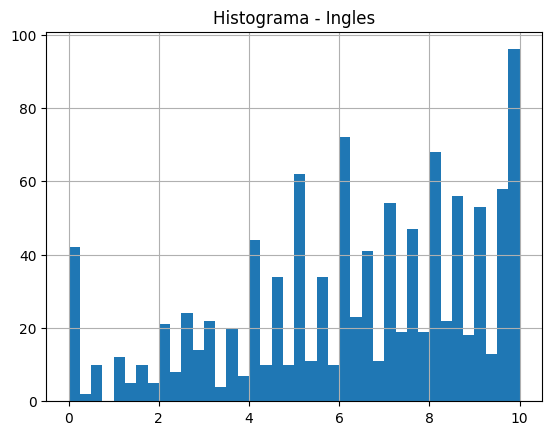

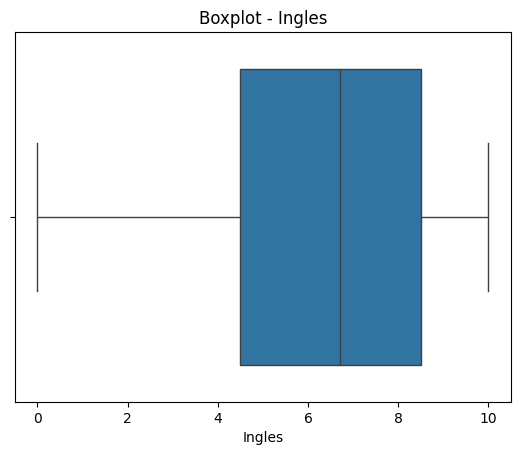

In [11]:
top6 = df[num_cols].var().sort_values(ascending=False).head(6).index.tolist()
print("Top 6 variáveis por variância:", top6)

for col in top6:
    plt.figure()
    df[col].hist(bins=40)
    plt.title(f"Histograma - {col}")
    plt.show()

    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

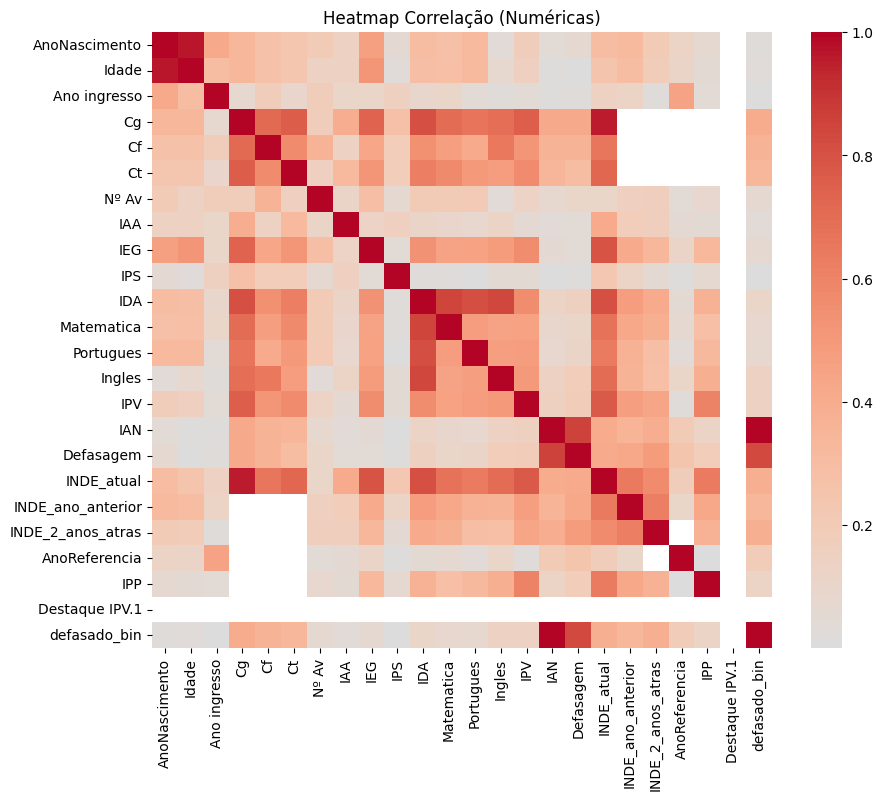

defasado_bin   IAN             0.992945
AnoNascimento  Idade           0.965522
INDE_atual     Cg              0.958953
Defasagem      IAN             0.855942
IDA            Matematica      0.847390
               Ingles          0.836527
Defasagem      defasado_bin    0.830161
Portugues      IDA             0.818294
Cg             IDA             0.806436
INDE_atual     IDA             0.805507
               IEG             0.789472
               IPV             0.767725
Ct             Cg              0.763899
IPV            Cg              0.755368
Cg             IEG             0.739374
INDE_atual     Ct              0.724958
Cf             Cg              0.713348
Matematica     Cg              0.702402
Ingles         INDE_atual      0.699389
               Cg              0.693485
dtype: float64

In [12]:
corr = df[num_cols].corr().abs()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Heatmap Correlação (Numéricas)")
plt.show()

corr_unstacked = corr.unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1] 
top_corr = corr_unstacked.sort_values(ascending=False).drop_duplicates().head(20)

display(top_corr)

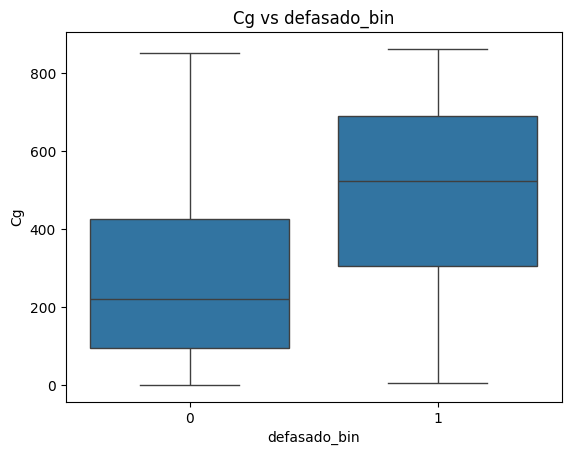

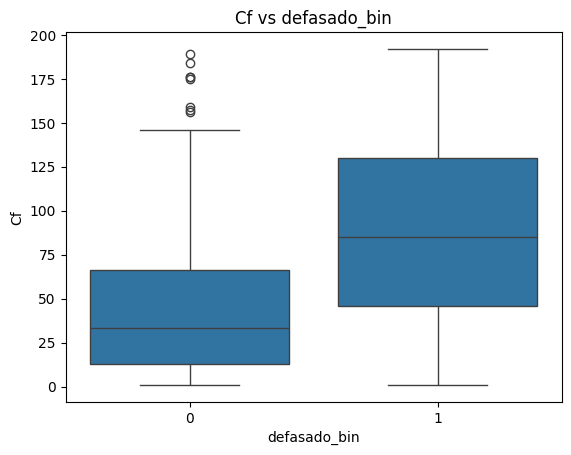

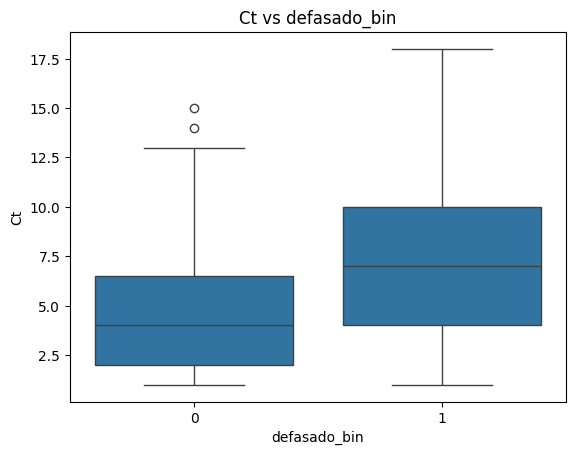

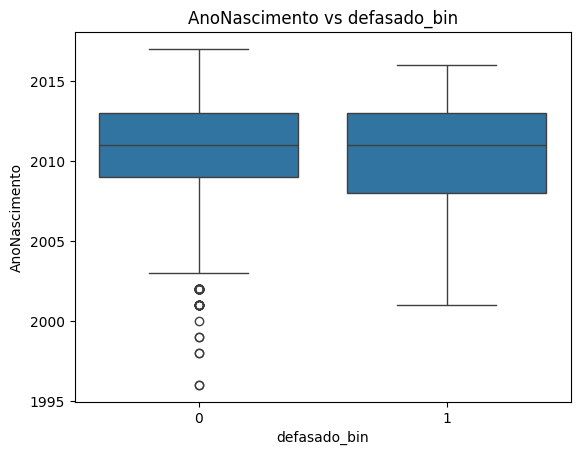

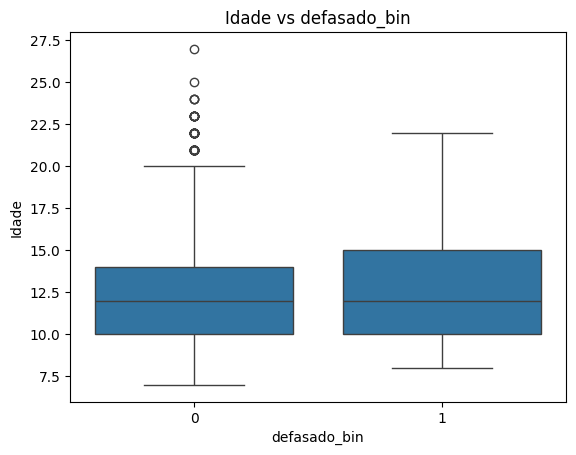

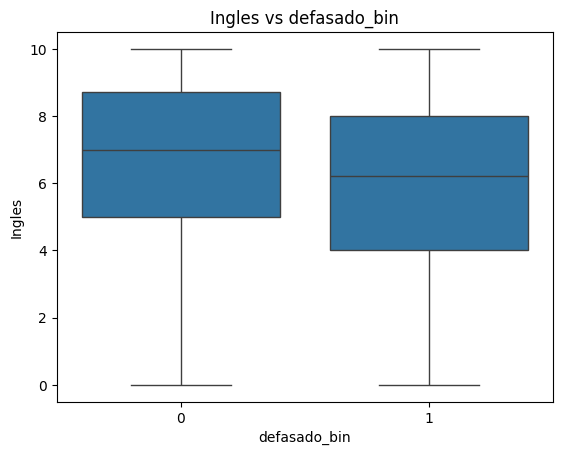

In [30]:
for col in top6:
    plt.figure()
    sns.boxplot(x=target_col, y=col, data=df)
    plt.title(f"{col} vs {target_col}")
    plt.show()

In [4]:
df = df.loc[:, df.nunique() > 1]
corrs = {}

for col in df.select_dtypes(include="number").columns:
    if col != "defasado_bin":
        corr = np.corrcoef(df[col].fillna(0), df["defasado_bin"])[0,1]
        corrs[col] = corr

sorted_corrs = sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True)

sorted_corrs[:10]

[('IAN', -0.9929448049370729),
 ('Defasagem', -0.8301614962518256),
 ('Cg', 0.26028543209290234),
 ('Cf', 0.25240500622621825),
 ('Ct', 0.24423770755207416),
 ('INDE_2_anos_atras', -0.19816411680505266),
 ('AnoReferencia', -0.19016739198930843),
 ('IPV', 0.16786249588902868),
 ('IPS', 0.1665942287222266),
 ('IEG', 0.14441536637097016)]

## Próximos Passos: Construindo o Baseline

### 1. Preparação dos Dados - `src/data/prepare_academic_dataset.py`

Com base nos insights desta EDA, um script automatizado prepara os dados:

**O que faz:**
- Seleciona apenas as variáveis de desempenho acadêmico relevantes:
  - `Matematica`, `Portugues`, `Ingles`, `IDA`, `Cg`, `Cf`, `Ct`
- Remove colunas irrelevantes ou com alto número de valores faltantes
- Define explicitamente a variável target: `defasado_bin` 
- Salva o dataset processado em `data/processed/dataset_academic.csv`
- Exporta os nomes de features e target em `artifacts/feature_cols.json`

**Executar:**
```bash
python src/data/prepare_academic_dataset.py
```

### 2. Treinamento do Modelo - `src/baseline/train_baseline.py`

O script de baseline realiza o treinamento inicial usando apenas as variáveis acadêmicas:

**O que faz:**
- Carrega o dataset preparado ou cria uma seleção mínima de features acadêmicas
- Implementa um pipeline completo:
  - **Impute**: Preenchimento de valores faltantes (mediana)
  - **Scale**: Normalização das features (StandardScaler)
  - **Model**: Regressão Logística para classificação binária
- Avalia o modelo com **validação cruzada estratificada** (5 splits)
- Calcula métricas: ROC-AUC, AUPRC (Average Precision), F1-Score
- Salva o modelo treinado em `artifacts/models/baseline_academico_model.joblib`
- Exporta relatório de performance em `artifacts/models/baseline_academico_report.json`

**Executar:**
```bash
make sanity  # Validar setup
python src/baseline/train_baseline.py
```

### Resultado Esperado

O baseline serve como ponto de referência (benchmark) para o desempenho de modelos mais complexos. Espera-se que modelos futuros com mais features ou técnicas avançadas superem este resultado.